## Setup import|

In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Set random seed for reproducibility
np.random.seed(42)

# 1. Load Data
df_haji_raw = pd.read_excel('DataBiayaHaji.xlsx', sheet_name='Data')
df_kurs_raw = pd.read_excel('KursTransaksiUSD.xlsx')
df_emas_raw = pd.read_csv('antam_prices.csv') # or check if we have another emas file or use antam/world gold

print("Biaya Haji raw shape:", df_haji_raw.shape)
print("Kurs raw shape:", df_kurs_raw.shape)
print("Emas raw shape:", df_emas_raw.shape)

Biaya Haji raw shape: (13, 12)
Kurs raw shape: (6240, 5)
Emas raw shape: (5002, 3)


In [2]:
print(df_emas_raw.head())
print(df_emas_raw.tail())
print("Columns of antam_prices:", df_emas_raw.columns)

         date  harga_jual  harga_beli
0  2010-01-04      408000         NaN
1  2010-01-05      410000         NaN
2  2010-01-06      410000         NaN
3  2010-01-07      412000         NaN
4  2010-01-08      410000         NaN
            date  harga_jual  harga_beli
4997  2026-07-27     2622000   2370000.0
4998  2026-07-28     2613000   2361000.0
4999  2026-07-29     2601000   2346000.0
5000  2026-07-30     2616000   2381000.0
5001  2026-07-31     2623000   2398000.0
Columns of antam_prices: Index(['date', 'harga_jual', 'harga_beli'], dtype='object')


## Preprocessing

In [3]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from statsmodels.tsa.holtwinters import ExponentialSmoothing

np.random.seed(42)

In [4]:
# --- 1. PREPROCESSING KURS ---
df_kurs = df_kurs_raw.copy()
df_kurs['Tanggal'] = pd.to_datetime(df_kurs['Tanggal'])
df_kurs = df_kurs.set_index('Tanggal').sort_index()
df_kurs_m = df_kurs['Kurs Jual'].resample('ME').mean().dropna()

model_kurs = ExponentialSmoothing(df_kurs_m, trend='add', damped_trend=False, seasonal=None, initialization_method='estimated')
fit_kurs = model_kurs.fit(optimized=True)

# Forecast Kurs up to 2070 (532 months from 2026-08)
start_sim_date = pd.Timestamp('2026-01-01')
end_sim_date = pd.Timestamp('2070-12-01')
all_months = pd.date_range(start='2026-01-01', end='2070-12-01', freq='MS')

# Forecast kurs
n_forecast_months = (2070 - df_kurs_m.index[-1].year) * 12 + (12 - df_kurs_m.index[-1].month)
pred_kurs_vals = fit_kurs.forecast(n_forecast_months)
pred_kurs_dates = pd.date_range(start=df_kurs_m.index[-1] + pd.DateOffset(months=1), periods=n_forecast_months, freq='ME')
s_kurs = pd.Series(pred_kurs_vals.values, index=pred_kurs_dates)

# Map kurs to MS dates
df_sim = pd.DataFrame({'Bulan': all_months})
df_sim['Tahun'] = df_sim['Bulan'].dt.year

def get_kurs(row):
    dt = row['Bulan']
    # find closest date in s_kurs or df_kurs_m
    if dt in df_kurs_m.index:
        return df_kurs_m.loc[dt]
    # match by month end
    me = dt + pd.offsets.MonthEnd(0)
    if me in s_kurs.index:
        return s_kurs.loc[me]
    elif me in df_kurs_m.index:
        return df_kurs_m.loc[me]
    else:
        return s_kurs.iloc[-1]

df_sim['Kurs'] = df_sim.apply(get_kurs, axis=1)

/tmp/ipykernel_103410/266616336.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_kurs['Tanggal'] = pd.to_datetime(df_kurs['Tanggal'])


In [5]:
# --- 2. PREPROCESSING & MODEL EMAS (GBM) ---
df_emas = df_emas_raw.copy()
df_emas['date'] = pd.to_datetime(df_emas['date'])
df_emas = df_emas.set_index('date').sort_index()
df_emas_m = df_emas['harga_jual'].resample('ME').mean().dropna()

log_ret = np.log(df_emas_m / df_emas_m.shift(1)).dropna()
u = log_ret.mean()
var = log_ret.var()
stdev = log_ret.std()
drift = u - 0.5 * var

# Monte Carlo generation
n_sim = 1000
months_to_forecast = (2070 - df_emas_m.index[-1].year) * 12 + (12 - df_emas_m.index[-1].month)
Z = np.random.standard_normal((months_to_forecast, n_sim))
periodic_returns = np.exp(drift + stdev * Z)

pred_path = np.zeros((months_to_forecast, n_sim))
last_p = df_emas_m.iloc[-1]
pred_path[0] = last_p * periodic_returns[0]
for t in range(1, months_to_forecast):
    pred_path[t] = pred_path[t-1] * periodic_returns[t]

# Mean monthly price
mean_gold_pred = np.mean(pred_path, axis=1)
pred_emas_dates = pd.date_range(start=df_emas_m.index[-1] + pd.DateOffset(months=1), periods=months_to_forecast, freq='ME')
s_emas = pd.Series(mean_gold_pred, index=pred_emas_dates)

def get_emas(row):
    dt = row['Bulan']
    me = dt + pd.offsets.MonthEnd(0)
    if me in df_emas_m.index:
        return df_emas_m.loc[me]
    elif me in s_emas.index:
        return s_emas.loc[me]
    else:
        return s_emas.iloc[-1]

df_sim['Harga_Emas_IDR_gr'] = df_sim.apply(get_emas, axis=1)

In [6]:
# --- 3. MODEL BIAYA HAJI (LOGISTIC) ---
# Clean df_haji_raw
df_haji = df_haji_raw.copy()
df_haji['Total haji regular'] = pd.to_numeric(df_haji['Total haji regular'], errors='coerce')
df_haji['Total Biaya Haji Furoda'] = pd.to_numeric(df_haji['Total Biaya Haji Furoda'], errors='coerce')

df_reg_clean = df_haji.dropna(subset=['Total haji regular'])
t_reg = df_reg_clean['Tahun'].values - 2014
y_reg = df_reg_clean['Total haji regular'].values

df_fur_clean = df_haji.dropna(subset=['Total Biaya Haji Furoda'])
t_fur = df_fur_clean['Tahun'].values - 2014
y_fur = df_fur_clean['Total Biaya Haji Furoda'].values

def logistic_model(t, K, r, P0):
    return K / (1 + ((K - P0) / P0) * np.exp(-r * t))

p0_reg = [150_000_000, 0.05, 59_270_000]
bounds_reg = ([110_000_000, 0.01, 55_000_000], [250_000_000, 0.12, 65_000_000])
popt_reg, _ = curve_fit(logistic_model, t_reg, y_reg, p0=p0_reg, bounds=bounds_reg)

p0_fur = [35_000, 0.04, 12_000]
bounds_fur = ([22_000, 0.01, 8_000], [50_000, 0.12, 15_000])
popt_fur, _ = curve_fit(logistic_model, t_fur, y_fur, p0=p0_fur, bounds=bounds_fur)

df_sim['t_logistic'] = df_sim['Tahun'] - 2014
df_sim['Biaya_Reguler'] = df_sim['t_logistic'].apply(lambda t: logistic_model(t, *popt_reg))
df_sim['Biaya_Plus_USD'] = 8000.0
df_sim['Biaya_Plus_IDR'] = df_sim['Biaya_Plus_USD'] * df_sim['Kurs']
df_sim['Biaya_Furoda_USD'] = df_sim['t_logistic'].apply(lambda t: logistic_model(t, *popt_fur))
df_sim['Biaya_Furoda_IDR'] = df_sim['Biaya_Furoda_USD'] * df_sim['Kurs']

print("Sample Proyeksi 2026-2030:")
print(df_sim[['Bulan', 'Kurs', 'Harga_Emas_IDR_gr', 'Biaya_Reguler', 'Biaya_Plus_IDR', 'Biaya_Furoda_IDR']].head(12))

Sample Proyeksi 2026-2030:
        Bulan          Kurs  Harga_Emas_IDR_gr  Biaya_Reguler  Biaya_Plus_IDR  \
0  2026-01-01  16912.240500       2.718000e+06   9.586503e+07    1.352979e+08   
1  2026-02-01  16909.794444       2.961857e+06   9.586503e+07    1.352784e+08   
2  2026-03-01  16996.087647       2.965806e+06   9.586503e+07    1.359687e+08   
3  2026-04-01  17226.465238       2.849567e+06   9.586503e+07    1.378117e+08   
4  2026-05-01  17633.354375       2.800097e+06   9.586503e+07    1.410668e+08   
5  2026-06-01  18012.915500       2.705500e+06   9.586503e+07    1.441033e+08   
6  2026-07-01  18097.603043       2.631871e+06   9.586503e+07    1.447808e+08   
7  2026-08-01  18113.705670       2.658143e+06   9.586503e+07    1.449096e+08   
8  2026-09-01  18129.808297       2.688432e+06   9.586503e+07    1.450385e+08   
9  2026-10-01  18145.910924       2.714294e+06   9.586503e+07    1.451673e+08   
10 2026-11-01  18162.013551       2.738527e+06   9.586503e+07    1.452961e+08   
1

## simulation

In [10]:
def run_simulation(nominal_bulanan=1_500_000, start_year=2026):
    sim_df = df_sim[df_sim['Tahun'] >= start_year].copy().reset_index(drop=True)
    
    saldo_idr = 0.0
    gram_emas = 0.0
    
    milestones = {
        'Rupiah': {
            'Reguler_DP': None, 'Reguler_Berangkat': None,
            'Plus_DP': None, 'Plus_Berangkat': None,
            'Furoda_Berangkat': None
        },
        'Emas': {
            'Reguler_DP': None, 'Reguler_Berangkat': None,
            'Plus_DP': None, 'Plus_Berangkat': None,
            'Furoda_Berangkat': None
        }
    }
    
    history = []
    
    for idx, row in sim_df.iterrows():
        t = row['Bulan']
        year = row['Tahun']
        kurs = row['Kurs']
        harga_emas = row['Harga_Emas_IDR_gr']
        
        biaya_reg = row['Biaya_Reguler']
        biaya_plus = row['Biaya_Plus_IDR']
        biaya_fur = row['Biaya_Furoda_IDR']
        
        dp_reg = 25_000_000.0
        dp_plus = 4000.0 * kurs
        
        # Accumulate
        saldo_idr += nominal_bulanan
        gram_emas += nominal_bulanan / harga_emas
        val_emas_idr = gram_emas * harga_emas
        
        # --- RUPIAH MILESTONES ---
        # DP Reguler
        if milestones['Rupiah']['Reguler_DP'] is None and saldo_idr >= dp_reg:
            milestones['Rupiah']['Reguler_DP'] = (t, year, saldo_idr)
        # DP Plus
        if milestones['Rupiah']['Plus_DP'] is None and saldo_idr >= dp_plus:
            milestones['Rupiah']['Plus_DP'] = (t, year, saldo_idr)
            
        # Check Keberangkatan Reguler (Tahun >= DP_Year + 26 AND Saldo >= Biaya_Reguler)
        if milestones['Rupiah']['Reguler_DP'] is not None and milestones['Rupiah']['Reguler_Berangkat'] is None:
            dp_year = milestones['Rupiah']['Reguler_DP'][1]
            if year >= dp_year + 26 and saldo_idr >= biaya_reg:
                milestones['Rupiah']['Reguler_Berangkat'] = (t, year, saldo_idr)
                
        # Check Keberangkatan Plus (Tahun >= DP_Year + 7 AND Saldo >= Biaya_Plus)
        if milestones['Rupiah']['Plus_DP'] is not None and milestones['Rupiah']['Plus_Berangkat'] is None:
            dp_year = milestones['Rupiah']['Plus_DP'][1]
            if year >= dp_year + 7 and saldo_idr >= biaya_plus:
                milestones['Rupiah']['Plus_Berangkat'] = (t, year, saldo_idr)
                
        # Check Keberangkatan Furoda (Saldo >= Biaya_Furoda)
        if milestones['Rupiah']['Furoda_Berangkat'] is None and saldo_idr >= biaya_fur:
            milestones['Rupiah']['Furoda_Berangkat'] = (t, year, saldo_idr)
            
        # --- EMAS MILESTONES ---
        # DP Reguler
        if milestones['Emas']['Reguler_DP'] is None and val_emas_idr >= dp_reg:
            milestones['Emas']['Reguler_DP'] = (t, year, val_emas_idr)
        # DP Plus
        if milestones['Emas']['Plus_DP'] is None and val_emas_idr >= dp_plus:
            milestones['Emas']['Plus_DP'] = (t, year, val_emas_idr)
            
        # Check Keberangkatan Reguler
        if milestones['Emas']['Reguler_DP'] is not None and milestones['Emas']['Reguler_Berangkat'] is None:
            dp_year = milestones['Emas']['Reguler_DP'][1]
            if year >= dp_year + 26 and val_emas_idr >= biaya_reg:
                milestones['Emas']['Reguler_Berangkat'] = (t, year, val_emas_idr)
                
        # Check Keberangkatan Plus
        if milestones['Emas']['Plus_DP'] is not None and milestones['Emas']['Plus_Berangkat'] is None:
            dp_year = milestones['Emas']['Plus_DP'][1]
            if year >= dp_year + 7 and val_emas_idr >= biaya_plus:
                milestones['Emas']['Plus_Berangkat'] = (t, year, val_emas_idr)
                
        # Check Keberangkatan Furoda
        if milestones['Emas']['Furoda_Berangkat'] is None and val_emas_idr >= biaya_fur:
            milestones['Emas']['Furoda_Berangkat'] = (t, year, val_emas_idr)
            
        history.append({
            'Bulan': t, 'Tahun': year,
            'Saldo_IDR': saldo_idr, 'Val_Emas_IDR': val_emas_idr,
            'Gram_Emas': gram_emas,
            'Biaya_Reguler': biaya_reg, 'Biaya_Plus': biaya_plus, 'Biaya_Furoda': biaya_fur,
            'DP_Reguler': dp_reg, 'DP_Plus': dp_plus
        })
        
    return pd.DataFrame(history), milestones

df_res_15m, ms_15m = run_simulation(3_000_000, 2026)

print("=== MILESTONES RP 1.500.000 / BULAN ===")
import pprint
pprint.pprint(ms_15m)

=== MILESTONES RP 1.500.000 / BULAN ===
{'Emas': {'Furoda_Berangkat': (Timestamp('2034-11-01 00:00:00'),
                               2034,
                               547386391.0219529),
          'Plus_Berangkat': (Timestamp('2034-01-01 00:00:00'),
                             2034,
                             470886589.5130454),
          'Plus_DP': (Timestamp('2027-11-01 00:00:00'),
                      2027,
                      74558232.35421865),
          'Reguler_Berangkat': (Timestamp('2052-01-01 00:00:00'),
                                2052,
                                5655022857.1891),
          'Reguler_DP': (Timestamp('2026-09-01 00:00:00'),
                         2026,
                         26200300.43934946)},
 'Rupiah': {'Furoda_Berangkat': (Timestamp('2044-06-01 00:00:00'),
                                 2044,
                                 666000000.0),
            'Plus_Berangkat': (Timestamp('2035-01-01 00:00:00'),
                          

In [11]:
# Check when Saldo Rupiah exceeds Biaya Furoda
df_furoda_rupiah = df_res_15m[df_res_15m['Saldo_IDR'] >= df_res_15m['Biaya_Furoda']]
if not df_furoda_rupiah.empty:
    print("Furoda Rupiah Lunas at:")
    print(df_furoda_rupiah.iloc[0][['Bulan', 'Tahun', 'Saldo_IDR', 'Biaya_Furoda']])
else:
    print("Furoda Rupiah NOT reached within 2070!")
    print("Max Saldo IDR at 2070:", df_res_15m.iloc[-1]['Saldo_IDR'])
    print("Biaya Furoda at 2070:", df_res_15m.iloc[-1]['Biaya_Furoda'])

Furoda Rupiah Lunas at:
Bulan           2044-06-01 00:00:00
Tahun                          2044
Saldo_IDR               666000000.0
Biaya_Furoda       665217622.058582
Name: 221, dtype: object


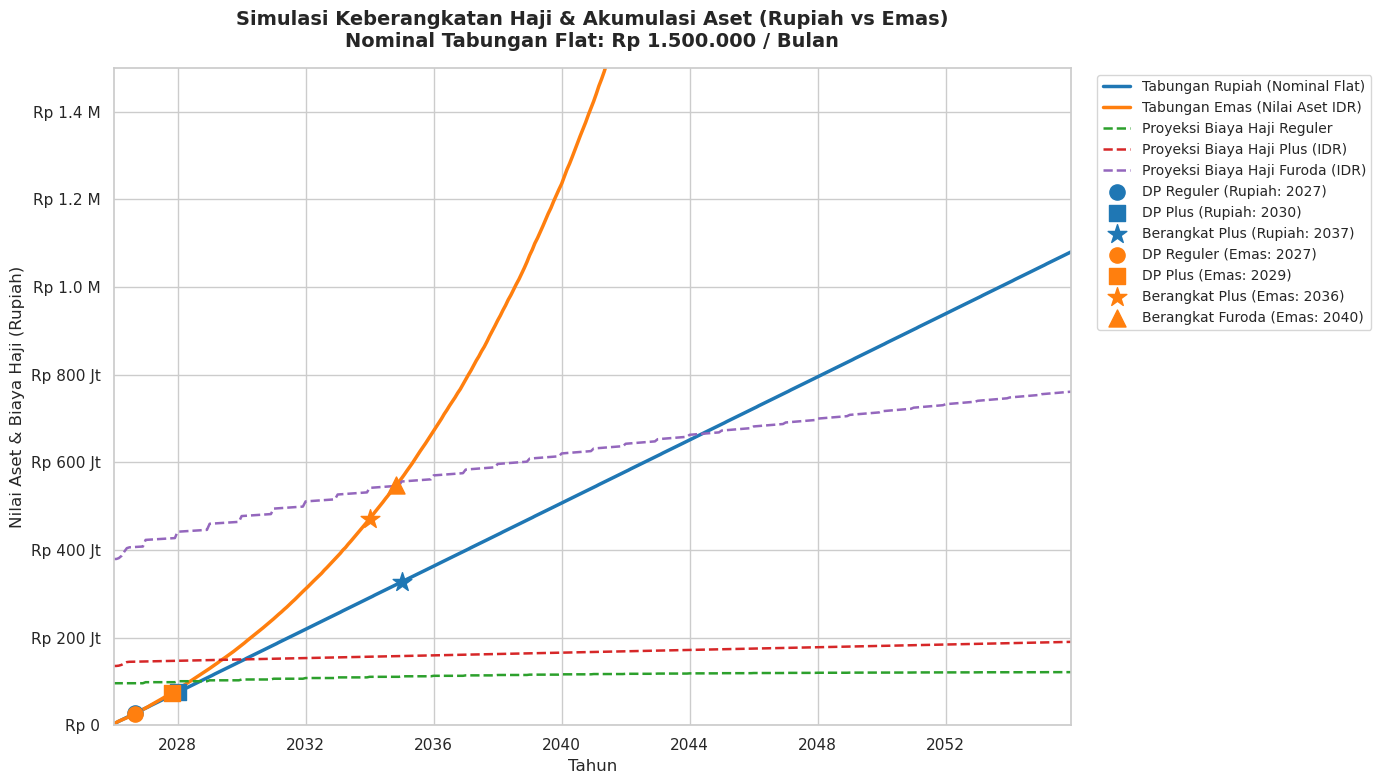

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

# Data plot from df_res_15m
plt.plot(df_res_15m['Bulan'], df_res_15m['Saldo_IDR'], label='Tabungan Rupiah (Nominal Flat)', color='#1f77b4', linewidth=2.5)
plt.plot(df_res_15m['Bulan'], df_res_15m['Val_Emas_IDR'], label='Tabungan Emas (Nilai Aset IDR)', color='#ff7f0e', linewidth=2.5)

plt.plot(df_res_15m['Bulan'], df_res_15m['Biaya_Reguler'], label='Proyeksi Biaya Haji Reguler', color='#2ca02c', linestyle='--', linewidth=1.8)
plt.plot(df_res_15m['Bulan'], df_res_15m['Biaya_Plus'], label='Proyeksi Biaya Haji Plus (IDR)', color='#d62728', linestyle='--', linewidth=1.8)
plt.plot(df_res_15m['Bulan'], df_res_15m['Biaya_Furoda'], label='Proyeksi Biaya Haji Furoda (IDR)', color='#9467bd', linestyle='--', linewidth=1.8)

# Add milestones markers
# Rupiah
if ms_15m['Rupiah']['Reguler_DP']:
    dp_t, dp_y, dp_val = ms_15m['Rupiah']['Reguler_DP']
    plt.scatter(dp_t, dp_val, color='#1f77b4', marker='o', s=120, zorder=5, label='DP Reguler (Rupiah: 2027)')
if ms_15m['Rupiah']['Plus_DP']:
    dp_t, dp_y, dp_val = ms_15m['Rupiah']['Plus_DP']
    plt.scatter(dp_t, dp_val, color='#1f77b4', marker='s', s=120, zorder=5, label='DP Plus (Rupiah: 2030)')
if ms_15m['Rupiah']['Plus_Berangkat']:
    brkt_t, brkt_y, brkt_val = ms_15m['Rupiah']['Plus_Berangkat']
    plt.scatter(brkt_t, brkt_val, color='#1f77b4', marker='*', s=200, zorder=5, label='Berangkat Plus (Rupiah: 2037)')

# Emas
if ms_15m['Emas']['Reguler_DP']:
    dp_t, dp_y, dp_val = ms_15m['Emas']['Reguler_DP']
    plt.scatter(dp_t, dp_val, color='#ff7f0e', marker='o', s=120, zorder=5, label='DP Reguler (Emas: 2027)')
if ms_15m['Emas']['Plus_DP']:
    dp_t, dp_y, dp_val = ms_15m['Emas']['Plus_DP']
    plt.scatter(dp_t, dp_val, color='#ff7f0e', marker='s', s=120, zorder=5, label='DP Plus (Emas: 2029)')
if ms_15m['Emas']['Plus_Berangkat']:
    brkt_t, brkt_y, brkt_val = ms_15m['Emas']['Plus_Berangkat']
    plt.scatter(brkt_t, brkt_val, color='#ff7f0e', marker='*', s=200, zorder=5, label='Berangkat Plus (Emas: 2036)')
if ms_15m['Emas']['Furoda_Berangkat']:
    brkt_t, brkt_y, brkt_val = ms_15m['Emas']['Furoda_Berangkat']
    plt.scatter(brkt_t, brkt_val, color='#ff7f0e', marker='^', s=150, zorder=5, label='Berangkat Furoda (Emas: 2040)')

# Formatting Y-axis
def rupiah_formatter(x, pos):
    if x >= 1e9:
        return f'Rp {x/1e9:.1f} M'
    elif x >= 1e6:
        return f'Rp {x/1e6:.0f} Jt'
    else:
        return f'Rp {x:,.0f}'

plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(rupiah_formatter))
plt.title('Simulasi Keberangkatan Haji & Akumulasi Aset (Rupiah vs Emas)\nNominal Tabungan Flat: Rp 1.500.000 / Bulan', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Nilai Aset & Biaya Haji (Rupiah)', fontsize=12)
plt.xlim(pd.Timestamp('2026-01-01'), pd.Timestamp('2055-12-01'))
plt.ylim(0, 1.5e9)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('simulasi_haji_ visual.png', dpi=300)
plt.show()

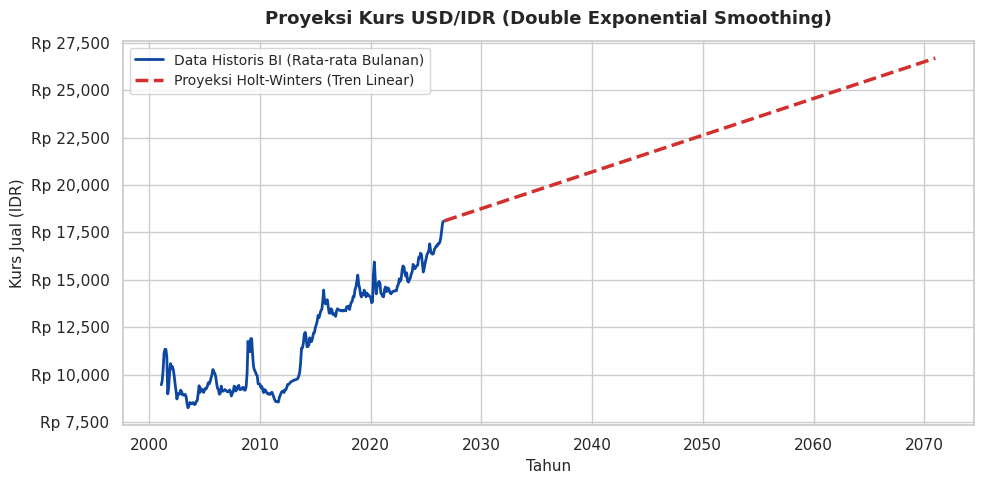

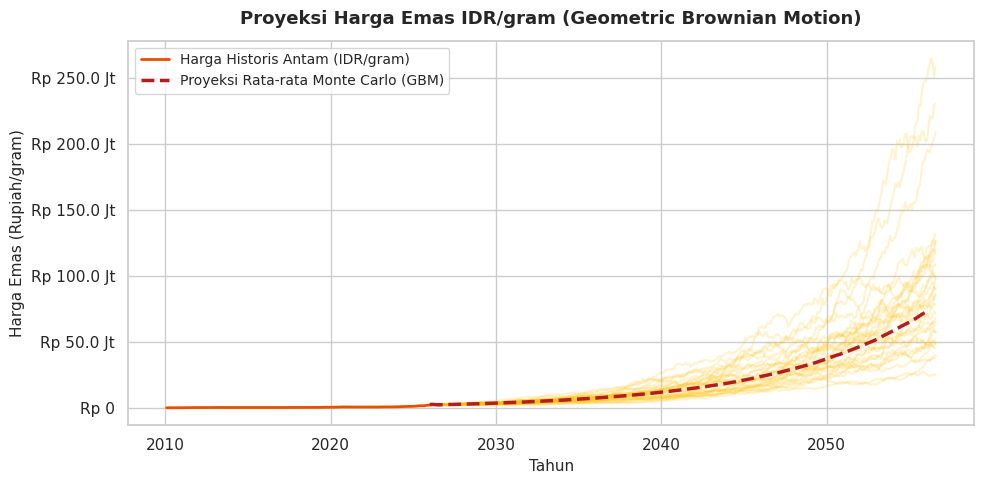

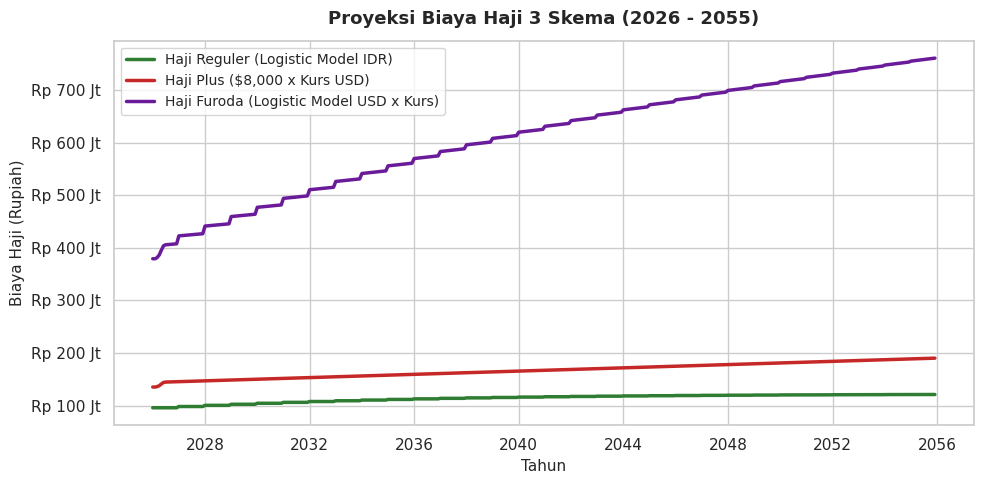

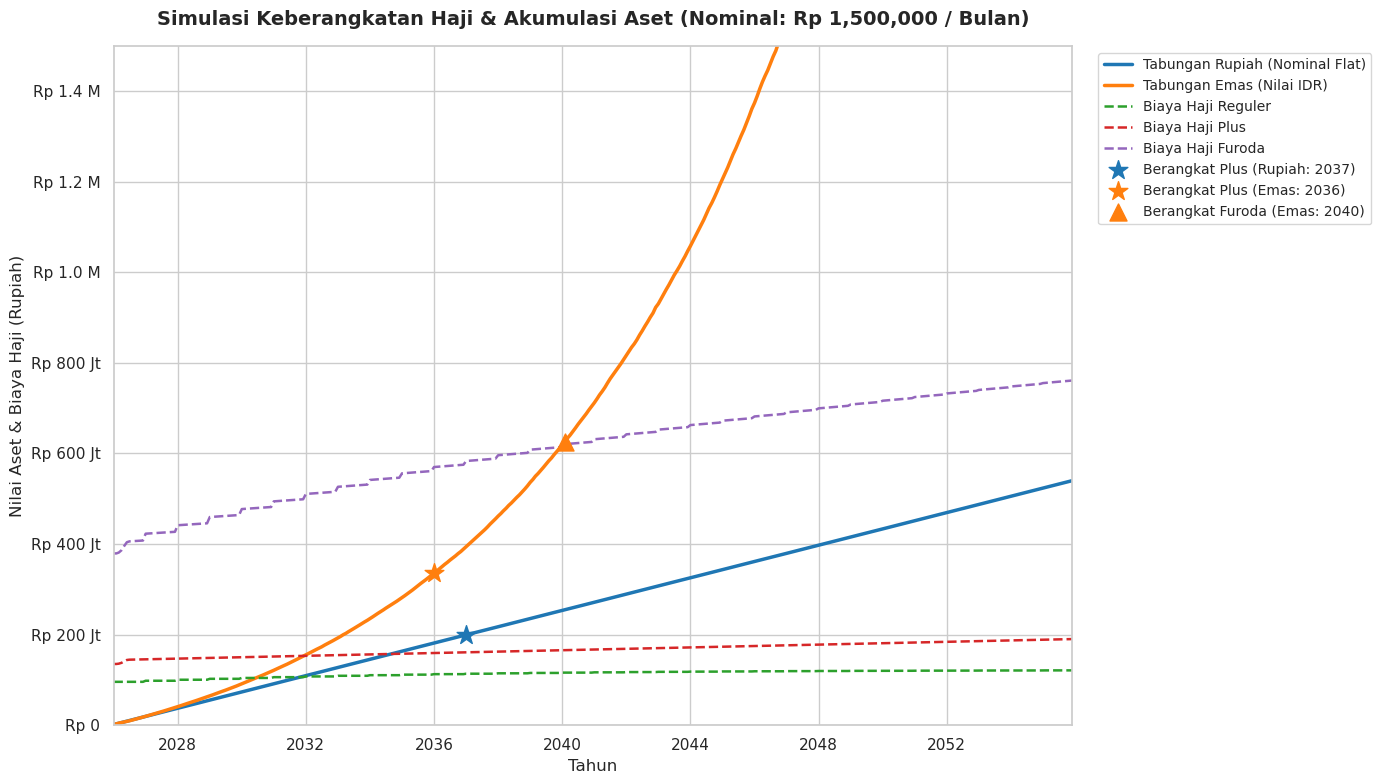

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.optimize import curve_fit
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings

warnings.filterwarnings('ignore')

# Global Setup & Random Seed for Reproducibility
np.random.seed(42)
sns.set_theme(style="whitegrid")


# ==========================================
# 1. PREPROCESSING & MODELING ENGINE
# ==========================================

def load_and_prepare_models():
    """Memuat data historis dan melatih model Holt-Winters, GBM, & Logistik."""
    df_haji_raw = pd.read_excel('DataBiayaHaji.xlsx', sheet_name='Data')
    df_kurs_raw = pd.read_excel('KursTransaksiUSD.xlsx')
    df_emas_raw = pd.read_csv('antam_prices.csv')

    # Fit Model Kurs (Holt-Winters)
    df_kurs = df_kurs_raw.copy()
    df_kurs['Tanggal'] = pd.to_datetime(df_kurs['Tanggal'], format='mixed', dayfirst=False)
    df_kurs = df_kurs.set_index('Tanggal').sort_index()
    df_kurs_m = df_kurs['Kurs Jual'].resample('M').mean().dropna()

    model_kurs = ExponentialSmoothing(
        df_kurs_m, trend='add', damped_trend=False, 
        seasonal=None, initialization_method='estimated'
    )
    fit_kurs = model_kurs.fit(optimized=True)

    # Fit Model Emas (GBM)
    df_emas = df_emas_raw.copy()
    df_emas['date'] = pd.to_datetime(df_emas['date'])
    df_emas = df_emas.set_index('date').sort_index()
    df_emas_m = df_emas['harga_jual'].resample('M').mean().dropna()

    log_ret = np.log(df_emas_m / df_emas_m.shift(1)).dropna()
    drift = log_ret.mean() - 0.5 * log_ret.var()
    stdev = log_ret.std()

    # Fit Model Biaya Haji (Logistik)
    df_haji = df_haji_raw.copy()
    df_haji['Total haji regular'] = pd.to_numeric(df_haji['Total haji regular'], errors='coerce')
    df_haji['Total Biaya Haji Furoda'] = pd.to_numeric(df_haji['Total Biaya Haji Furoda'], errors='coerce')

    df_reg_clean = df_haji.dropna(subset=['Total haji regular'])
    t_reg = df_reg_clean['Tahun'].values - 2014
    y_reg = df_reg_clean['Total haji regular'].values

    df_fur_clean = df_haji.dropna(subset=['Total Biaya Haji Furoda'])
    t_fur = df_fur_clean['Tahun'].values - 2014
    y_fur = df_fur_clean['Total Biaya Haji Furoda'].values

    def logistic_model(t, K, r, P0):
        return K / (1 + ((K - P0) / P0) * np.exp(-r * t))

    p0_reg = [150_000_000, 0.05, 59_270_000]
    bounds_reg = ([110_000_000, 0.01, 55_000_000], [250_000_000, 0.12, 65_000_000])
    popt_reg, _ = curve_fit(logistic_model, t_reg, y_reg, p0=p0_reg, bounds=bounds_reg)

    p0_fur = [35_000, 0.04, 12_000]
    bounds_fur = ([22_000, 0.01, 8_000], [50_000, 0.12, 15_000])
    popt_fur, _ = curve_fit(logistic_model, t_fur, y_fur, p0=p0_fur, bounds=bounds_fur)

    return fit_kurs, df_kurs_m, df_emas_m, drift, stdev, popt_reg, popt_fur, logistic_model


# ==========================================
# 2. PROJECTION GENERATOR
# ==========================================

def generate_full_projections(start_year=2026, end_year=2070):
    """Menghasilkan proyeksi bulanan makroekonomi dan biaya haji."""
    fit_kurs, df_kurs_m, df_emas_m, drift, stdev, popt_reg, popt_fur, logistic_model = load_and_prepare_models()

    all_months = pd.date_range(start=f'{start_year}-01-01', end=f'{end_year}-12-01', freq='MS')
    df_sim = pd.DataFrame({'Bulan': all_months})
    df_sim['Tahun'] = df_sim['Bulan'].dt.year

    # Proyeksi Kurs
    n_months = (end_year - df_kurs_m.index[-1].year) * 12 + (12 - df_kurs_m.index[-1].month)
    pred_kurs_vals = fit_kurs.forecast(n_months)
    pred_kurs_dates = pd.date_range(start=df_kurs_m.index[-1] + pd.DateOffset(months=1), periods=n_months, freq='M')
    s_kurs = pd.Series(pred_kurs_vals.values, index=pred_kurs_dates)

    # Proyeksi Emas (Monte Carlo)
    n_sim = 1000
    Z = np.random.standard_normal((n_months, n_sim))
    periodic_returns = np.exp(drift + stdev * Z)
    pred_path = np.zeros((n_months, n_sim))
    pred_path[0] = df_emas_m.iloc[-1] * periodic_returns[0]
    for t in range(1, n_months):
        pred_path[t] = pred_path[t-1] * periodic_returns[t]

    mean_gold_pred = np.mean(pred_path, axis=1)
    s_emas = pd.Series(mean_gold_pred, index=pred_kurs_dates)

    def get_proj(dt, series, hist):
        me = dt + pd.offsets.MonthEnd(0)
        return series.loc[me] if me in series.index else (hist.loc[me] if me in hist.index else series.iloc[-1])

    df_sim['Kurs'] = df_sim['Bulan'].apply(lambda dt: get_proj(dt, s_kurs, df_kurs_m))
    df_sim['Harga_Emas_IDR_gr'] = df_sim['Bulan'].apply(lambda dt: get_proj(dt, s_emas, df_emas_m))
    df_sim['t_log'] = df_sim['Tahun'] - 2014
    df_sim['Biaya_Reguler'] = df_sim['t_log'].apply(lambda t: logistic_model(t, *popt_reg))
    df_sim['Biaya_Plus'] = 8000.0 * df_sim['Kurs']
    df_sim['Biaya_Furoda'] = df_sim['t_log'].apply(lambda t: logistic_model(t, *popt_fur)) * df_sim['Kurs']

    return df_sim, df_kurs_m, s_kurs, df_emas_m, s_emas, pred_path, pred_kurs_dates


# ==========================================
# 3. VISUALIZATION EXECUTOR
# ==========================================

def plot_all_breakdown_graphs(nominal_bulanan=1_500_000, start_year=2026):
    """Mencetak 4 grafik visualisasi (3 breakdown prediksi + 1 simulasi gabungan)."""
    df_sim, df_kurs_m, s_kurs, df_emas_m, s_emas, pred_path, pred_kurs_dates = generate_full_projections(start_year, 2070)

    # --- Grafik 1: Kurs USD/IDR ---
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(df_kurs_m.index, df_kurs_m.values, label='Data Historis BI (Rata-rata Bulanan)', color='#0d47a1', linewidth=2)
    ax.plot(s_kurs.index, s_kurs.values, label='Proyeksi Holt-Winters (Tren Linear)', color='#d32f2f', linestyle='--', linewidth=2.5)
    ax.set_title('Proyeksi Kurs USD/IDR (Double Exponential Smoothing)', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Tahun', fontsize=11)
    ax.set_ylabel('Kurs Jual (IDR)', fontsize=11)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'Rp {x:,.0f}'))
    ax.legend(loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.show()

    # --- Grafik 2: Harga Emas ---
    fig, ax = plt.subplots(figsize=(10, 5))
    sub_gold = df_sim[df_sim['Tahun'] <= 2055]
    months_limit = len(sub_gold)

    for i in range(30):
        ax.plot(pred_kurs_dates[:months_limit], pred_path[:months_limit, i], color='#ffc107', alpha=0.2)

    ax.plot(df_emas_m.index, df_emas_m.values, label='Harga Historis Antam (IDR/gram)', color='#e65100', linewidth=2)
    ax.plot(sub_gold['Bulan'], sub_gold['Harga_Emas_IDR_gr'], label='Proyeksi Rata-rata Monte Carlo (GBM)', color='#b71c1c', linestyle='--', linewidth=2.5)
    ax.set_title('Proyeksi Harga Emas IDR/gram (Geometric Brownian Motion)', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Tahun', fontsize=11)
    ax.set_ylabel('Harga Emas (Rupiah/gram)', fontsize=11)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'Rp {x/1e6:.1f} Jt' if x >= 1e6 else f'Rp {x:,.0f}'))
    ax.legend(loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.show()

    # --- Grafik 3: Biaya Haji 3 Skema ---
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(sub_gold['Bulan'], sub_gold['Biaya_Reguler'], label='Haji Reguler (Logistic Model IDR)', color='#2e7d32', linewidth=2.5)
    ax.plot(sub_gold['Bulan'], sub_gold['Biaya_Plus'], label='Haji Plus ($8,000 x Kurs USD)', color='#c62828', linewidth=2.5)
    ax.plot(sub_gold['Bulan'], sub_gold['Biaya_Furoda'], label='Haji Furoda (Logistic Model USD x Kurs)', color='#6a1b9a', linewidth=2.5)
    ax.set_title('Proyeksi Biaya Haji 3 Skema (2026 - 2055)', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Tahun', fontsize=11)
    ax.set_ylabel('Biaya Haji (Rupiah)', fontsize=11)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'Rp {x/1e6:.0f} Jt' if x >= 1e6 else f'Rp {x:,.0f}'))
    ax.legend(loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.show()

    # --- Grafik 4: Akumulasi Tabungan VS Biaya Haji (Gabungan) ---
    saldo_idr, gram_emas = 0.0, 0.0
    history = []
    
    m = {
        'Rupiah': {'Reguler_DP': None, 'Reguler_Berangkat': None, 'Plus_DP': None, 'Plus_Berangkat': None, 'Furoda_Berangkat': None},
        'Emas': {'Reguler_DP': None, 'Reguler_Berangkat': None, 'Plus_DP': None, 'Plus_Berangkat': None, 'Furoda_Berangkat': None}
    }

    for _, row in df_sim.iterrows():
        t, year, kurs, harga_emas = row['Bulan'], row['Tahun'], row['Kurs'], row['Harga_Emas_IDR_gr']
        biaya_reg, biaya_plus, biaya_fur = row['Biaya_Reguler'], row['Biaya_Plus'], row['Biaya_Furoda']

        dp_reg = 25_000_000.0
        dp_plus = 4000.0 * kurs

        saldo_idr += nominal_bulanan
        gram_emas += nominal_bulanan / harga_emas
        val_emas = gram_emas * harga_emas

        # Track Milestones Rupiah
        if not m['Rupiah']['Reguler_DP'] and saldo_idr >= dp_reg: m['Rupiah']['Reguler_DP'] = (t, year, saldo_idr)
        if not m['Rupiah']['Plus_DP'] and saldo_idr >= dp_plus: m['Rupiah']['Plus_DP'] = (t, year, saldo_idr)
        if m['Rupiah']['Reguler_DP'] and not m['Rupiah']['Reguler_Berangkat']:
            if year >= m['Rupiah']['Reguler_DP'][1] + 26 and saldo_idr >= biaya_reg: m['Rupiah']['Reguler_Berangkat'] = (t, year, saldo_idr)
        if m['Rupiah']['Plus_DP'] and not m['Rupiah']['Plus_Berangkat']:
            if year >= m['Rupiah']['Plus_DP'][1] + 7 and saldo_idr >= biaya_plus: m['Rupiah']['Plus_Berangkat'] = (t, year, saldo_idr)
        if not m['Rupiah']['Furoda_Berangkat'] and saldo_idr >= biaya_fur: m['Rupiah']['Furoda_Berangkat'] = (t, year, saldo_idr)

        # Track Milestones Emas
        if not m['Emas']['Reguler_DP'] and val_emas >= dp_reg: m['Emas']['Reguler_DP'] = (t, year, val_emas)
        if not m['Emas']['Plus_DP'] and val_emas >= dp_plus: m['Emas']['Plus_DP'] = (t, year, val_emas)
        if m['Emas']['Reguler_DP'] and not m['Emas']['Reguler_Berangkat']:
            if year >= m['Emas']['Reguler_DP'][1] + 26 and val_emas >= biaya_reg: m['Emas']['Reguler_Berangkat'] = (t, year, val_emas)
        if m['Emas']['Plus_DP'] and not m['Emas']['Plus_Berangkat']:
            if year >= m['Emas']['Plus_DP'][1] + 7 and val_emas >= biaya_plus: m['Emas']['Plus_Berangkat'] = (t, year, val_emas)
        if not m['Emas']['Furoda_Berangkat'] and val_emas >= biaya_fur: m['Emas']['Furoda_Berangkat'] = (t, year, val_emas)

        history.append({'Bulan': t, 'Tahun': year, 'Saldo_IDR': saldo_idr, 'Val_Emas': val_emas, 'Biaya_Reg': biaya_reg, 'Biaya_Plus': biaya_plus, 'Biaya_Fur': biaya_fur})

    df_res = pd.DataFrame(history)

    fig, ax = plt.subplots(figsize=(14, 8))
    ax.plot(df_res['Bulan'], df_res['Saldo_IDR'], label='Tabungan Rupiah (Nominal Flat)', color='#1f77b4', linewidth=2.5)
    ax.plot(df_res['Bulan'], df_res['Val_Emas'], label='Tabungan Emas (Nilai IDR)', color='#ff7f0e', linewidth=2.5)
    ax.plot(df_res['Bulan'], df_res['Biaya_Reg'], label='Biaya Haji Reguler', color='#2ca02c', linestyle='--', linewidth=1.8)
    ax.plot(df_res['Bulan'], df_res['Biaya_Plus'], label='Biaya Haji Plus', color='#d62728', linestyle='--', linewidth=1.8)
    ax.plot(df_res['Bulan'], df_res['Biaya_Fur'], label='Biaya Haji Furoda', color='#9467bd', linestyle='--', linewidth=1.8)

    # Plot Markers
    if m['Rupiah']['Plus_Berangkat']:
        ax.scatter(m['Rupiah']['Plus_Berangkat'][0], m['Rupiah']['Plus_Berangkat'][2], color='#1f77b4', marker='*', s=200, zorder=5, label='Berangkat Plus (Rupiah: 2037)')
    if m['Emas']['Plus_Berangkat']:
        ax.scatter(m['Emas']['Plus_Berangkat'][0], m['Emas']['Plus_Berangkat'][2], color='#ff7f0e', marker='*', s=200, zorder=5, label='Berangkat Plus (Emas: 2036)')
    if m['Emas']['Furoda_Berangkat']:
        ax.scatter(m['Emas']['Furoda_Berangkat'][0], m['Emas']['Furoda_Berangkat'][2], color='#ff7f0e', marker='^', s=150, zorder=5, label='Berangkat Furoda (Emas: 2040)')

    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'Rp {x/1e9:.1f} M' if x >= 1e9 else (f'Rp {x/1e6:.0f} Jt' if x >= 1e6 else f'Rp {x:,.0f}')))
    ax.set_title(f'Simulasi Keberangkatan Haji & Akumulasi Aset (Nominal: Rp {nominal_bulanan:,.0f} / Bulan)', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Tahun', fontsize=12)
    ax.set_ylabel('Nilai Aset & Biaya Haji (Rupiah)', fontsize=12)
    ax.set_xlim(pd.Timestamp(f'{start_year}-01-01'), pd.Timestamp('2055-12-01'))
    ax.set_ylim(0, 1.5e9)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.show()

# Driver Execution
if __name__ == '__main__':
    plot_all_breakdown_graphs(nominal_bulanan=1_500_000, start_year=2026)